In [1]:
import os, json, gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io as sio

from tqdm.notebook import tqdm

from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")
from src.preprocess import EmgEncoder
from src.model import ResNet1d

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# データの読み込み

In [4]:
train = sio.loadmat("../data/train.mat")
test = sio.loadmat("../data/test.mat")

X = []
y = []
test_input = []

# ユーザーごとに前処理を行う
users = ["0001", "0002", "0003", "0004"]
encoders = {}
for user in tqdm(users, desc="Preprocess data"):
    train_x = train[user][0][0][0]
    train_y = train[user][0][0][1]
    test_x = test[user][0][0][0]
    
    input_encoder = EmgEncoder()
    train_x = input_encoder.fit_transform(train_x)
    test_x = input_encoder.transform(test_x)
    
    train_y = train_y.transpose(0, 2, 1)
    output_encoder = []
    for v_axis in range(3):
        mm = MinMaxScaler()
        train_y[:, :, v_axis] = mm.fit_transform(train_y[:, :, v_axis])
        output_encoder.append(mm)
        
        
    encoders[user] = (input_encoder, output_encoder)
    X.append(train_x)
    y.append(train_y)
    test_input.append(test_x)

X[0].shape, y[0].shape, test_input[0].shape

Preprocess data:   0%|          | 0/4 [00:00<?, ?it/s]

((319, 1000, 16), (319, 30, 3), (319, 1000, 16))

# DataSetの作成

In [6]:
class CustomDataset(Dataset):
    def __init__(self, x, y, v_axis, num_users=4):
        self.x = x
        self.y = y
        self.v_axis = v_axis
        self.num_users = num_users
        self.num_trials = [xi.shape[0] for xi in self.x]
    
    def __len__(self):
        return sum(self.num_trials)
    
    def __getitem__(self, idx):
        user_id = 0
        while idx >= self.num_trials[user_id]:
            idx -= self.num_trials[user_id]
            user_id += 1
        
        x = torch.tensor(self.x[user_id][idx, :, :].transpose(1, 0), dtype=torch.float32)
        y = torch.tensor(self.y[user_id][idx, :, self.v_axis], dtype=torch.float32)
        
        return x, y

v_axis = 0
dataset = CustomDataset(X, y, v_axis)

sample_x, sapmle_y = next(iter(dataset))
sample_x.shape, sapmle_y.shape

(torch.Size([16, 1000]), torch.Size([30]))

# 学習

In [7]:
def build_model(learning_rate):
    model = ResNet1d()
    loss_function = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    return model, loss_function, optimizer

def train_1epoch(model, loss_fn, optimizer, train_loader):
    total_loss = 0
    for i, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

def valid_1epoch(model, loss_fn, valid_loader):
    total_loss = 0
    with torch.no_grad():
        for i, (x, y) in enumerate(valid_loader):
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
            total_loss += loss_fn(pred, y).item()
        
    return total_loss / len(valid_loader)

Axis 0, Fold 0:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 86, valid loss: 0.02864


Axis 0, Fold 1:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 16, valid loss: 0.02346


Axis 0, Fold 2:   0%|          | 0/100 [00:00<?, ?it/s]

...

  Best epoch: 91, valid loss: 0.03416


Axis 0, Fold 8:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 46, valid loss: 0.02818


Axis 0, Fold 9:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 11, valid loss: 0.03033


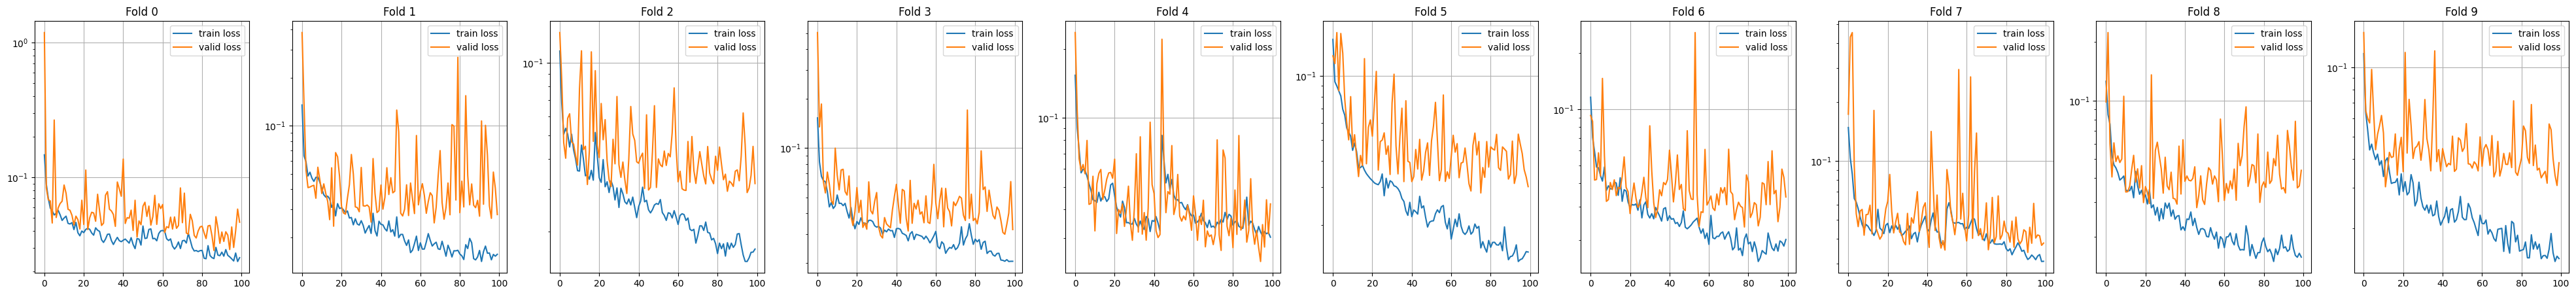

Axis 1, Fold 0:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 99, valid loss: 0.03333


Axis 1, Fold 1:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 93, valid loss: 0.02431


Axis 1, Fold 2:   0%|          | 0/100 [00:00<?, ?it/s]

...

  Best epoch: 95, valid loss: 0.02766


Axis 1, Fold 8:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 18, valid loss: 0.02972


Axis 1, Fold 9:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 96, valid loss: 0.02635


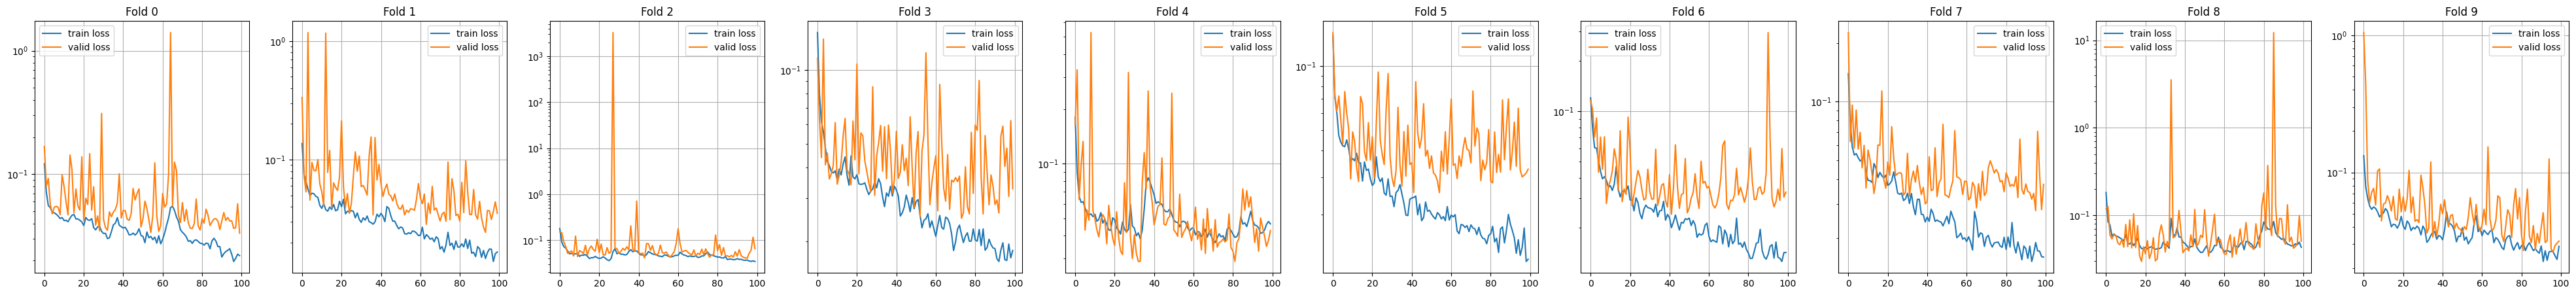

Axis 2, Fold 0:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 69, valid loss: 0.03160


Axis 2, Fold 1:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 33, valid loss: 0.02578


Axis 2, Fold 2:   0%|          | 0/100 [00:00<?, ?it/s]

...

  Best epoch: 99, valid loss: 0.03359


Axis 2, Fold 8:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 20, valid loss: 0.02504


Axis 2, Fold 9:   0%|          | 0/100 [00:00<?, ?it/s]

  Best epoch: 85, valid loss: 0.02823


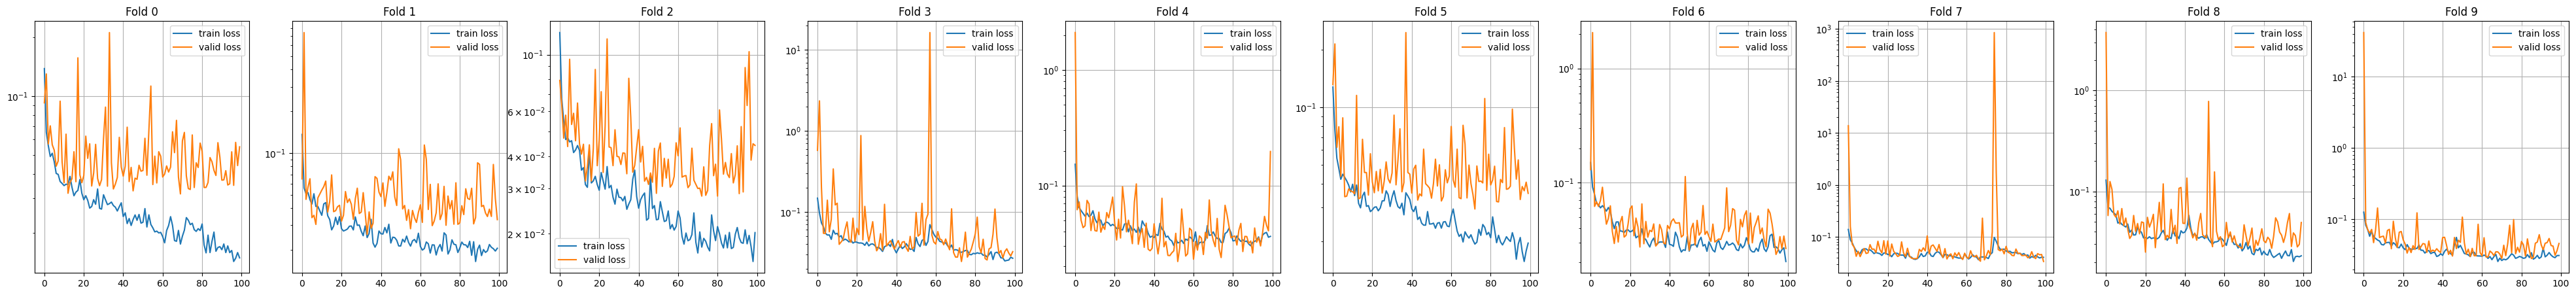

In [11]:
batch_size = 30
epochs = 100
learning_rate = 10e-3
num_splits = 10
num_workers = 12
outdir = "../models/ResNed_v2"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not os.path.isdir(outdir):
    os.mkdir(outdir)

for axis in range(3):
    history = []
    kf = KFold(n_splits=num_splits, shuffle=True, random_state=42)
    for i, (train_idx, valid_idx) in enumerate(kf.split(range(len(dataset)))):
        train_dataset = torch.utils.data.Subset(dataset, train_idx)
        valid_dataset = torch.utils.data.Subset(dataset, valid_idx)
        
        train_loader = torch.utils.data.DataLoader(
            train_dataset,
            batch_size=batch_size,
            num_workers=num_workers,
            shuffle=True
        )
        valid_loader = torch.utils.data.DataLoader(
            valid_dataset,
            batch_size=batch_size,
            num_workers=num_workers,
            shuffle=False
        )
        
        model, loss_fn, optimizer = build_model(learning_rate)
        
        model.to(device)
        history_1epoch = {"train": [], "valid": []}
        best_value = 10e9
        best_epoch = 0
        for epoch in tqdm(range(epochs), desc=f"Axis {axis}, Fold {i}"):
            model.train()
            train_loss = train_1epoch(model, loss_fn, optimizer, train_loader)
            model.eval()
            valid_loss = valid_1epoch(model, loss_fn, valid_loader)
            # print(f"[Epoch {epoch}] train loss: {train_loss:.5f}, valid loss: {valid_loss:.5f}")
            history_1epoch["train"].append(train_loss)
            history_1epoch["valid"].append(valid_loss)
            
            if valid_loss < best_value:
                # print(f"+++++ Saved as Best-Epoch: {epoch} ++++++")
                torch.save(model, os.path.join(outdir, f"Axis{axis}_Fold{i}_BestEpoch.pt"))
                best_value = valid_loss
                best_epoch = epoch
        
        history.append(history_1epoch)
        
        torch.save(model, os.path.join(outdir, f"Axis{axis}_Fold{i}_FinalEpoch.pt"))
        print("=======================================")
        print(f"  Best epoch: {best_epoch}, valid loss: {best_value:.5f}")
        print("=======================================")
    
    fig = plt.figure(figsize=(5*num_splits, 5))
    for i in range(num_splits):
        ax = fig.add_subplot(1, num_splits, i+1)
        ax.plot(history[i]["train"], label="train loss")
        ax.plot(history[i]["valid"], label="valid loss")
        ax.set_title(f"Fold {i}")
        # ax.set_ylim([0.002, 0.5])
        ax.set_yscale("log")
        ax.legend()
        ax.grid()
    plt.savefig(os.path.join(outdir, f"Axis{axis}_LearningCurve.png"), format="png")
    plt.show()

# モデルの評価

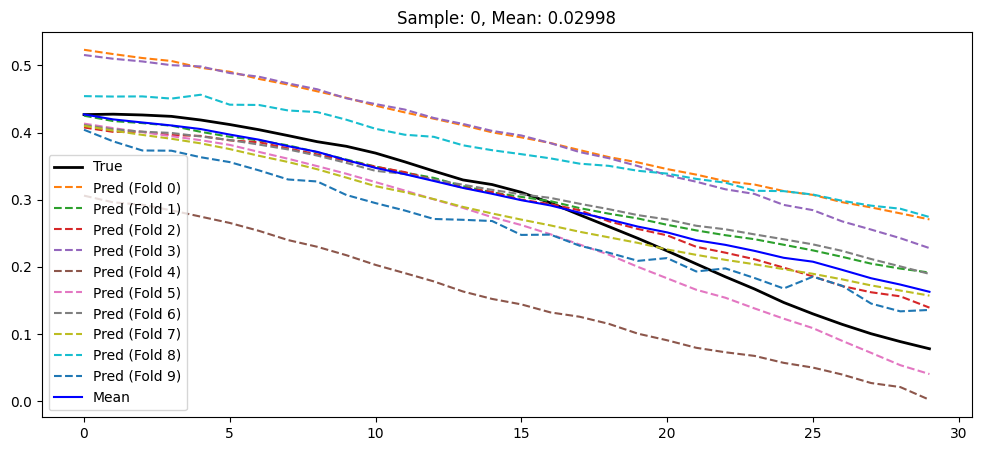

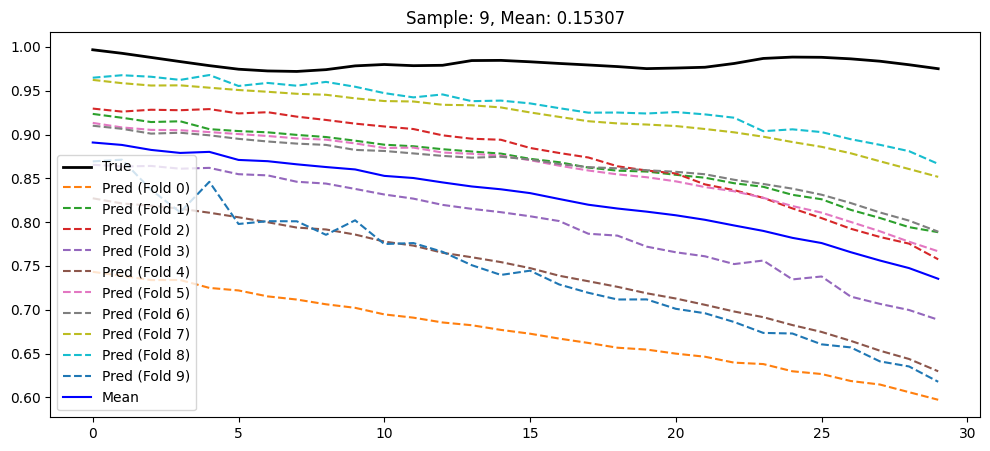

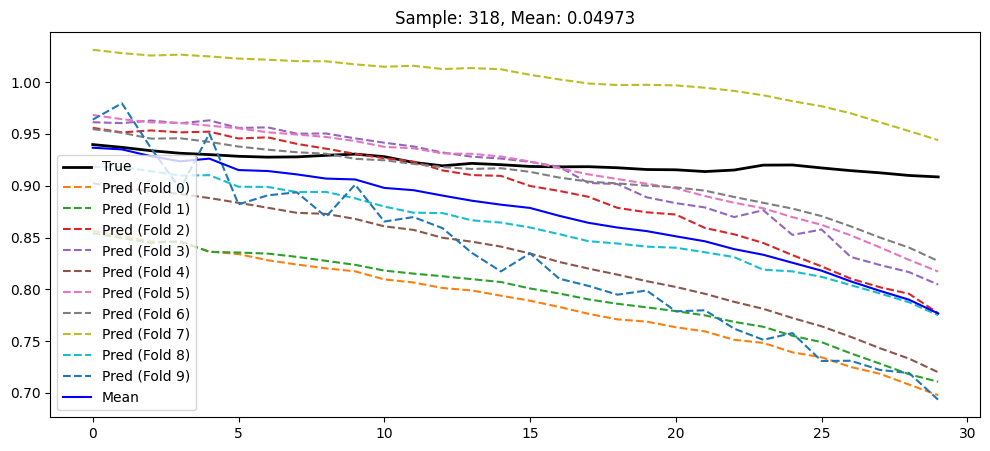

In [17]:
axis = 0

def show_test_pred(sample_id: int=0):
    sample_x = X[0][sample_id, :, :].transpose(1, 0).reshape(1, 16, 1000)
    sample_y = y[0][sample_id, :, axis]
    preds = []
    fig = plt.figure(figsize=(12, 5))
    plt.plot(sample_y, label="True", lw=2, color="black")
    for i in range(num_splits):
        model = torch.load(f"../models/ResNed_v2/Axis{axis}_Fold{i}_BestEpoch.pt", weights_only=False)
        model.to("cpu")
        pred_y = model(torch.tensor(sample_x, dtype=torch.float32)).detach().numpy()
        preds.append(pred_y[0])
        plt.plot(pred_y[0], label=f"Pred (Fold {i})", ls="--", color=f"C{i+1}")
        # plt.plot((pred_y[0]-1)*-1, label=f"Pred (Fold {i}, reversed)", ls="-.", color=f"C{i+1}")
    
    mean_pred = (np.mean(preds, axis=0))
    plt.plot(mean_pred, label="Mean", color="Blue", lw=1.5)
    # plt.plot(pred_rev, label="Mean (reversed)", color="Red", lw=1.5)

    mean_error = mean_absolute_error(sample_y, mean_pred)
    plt.legend()
    plt.title(f"Sample: {sample_id}, Mean: {mean_error:.5f}")
    plt.show()
    
for i in [0, 9, 318]:
    show_test_pred(i)

In [28]:
def evaluate(model, dataloader):
    preds = []
    with torch.no_grad():
        for i, (x, y) in enumerate(dataloader):
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
            pred = pred.to("cpu")
            preds.append(pred.detach().numpy())
    
    return np.array(preds)

oof = np.concat([np.zeros_like(yi) for yi in y])
kf = KFold(n_splits=num_splits, shuffle=True, random_state=42)

with tqdm(total=num_splits*3) as pbar:
    for i, (_, valid_idx) in enumerate(kf.split(range(len(dataset)))):
        valid_dataset = torch.utils.data.Subset(dataset, valid_idx)
        valid_loader = DataLoader(
            valid_dataset,
            batch_size=1,
            num_workers=num_workers,
            shuffle=False
        )
        
        for v_axis in range(3):
            model = torch.load(os.path.join(outdir, f"Axis{v_axis}_Fold{i}_BestEpoch.pt"))
            model.to(device)
            model.eval()
            pred = evaluate(model, valid_loader)
            oof[valid_idx, :, v_axis] = pred.transpose(0, 2, 1).reshape(-1, 30)
            
            pbar.update(1)
            


  0%|          | 0/30 [00:00<?, ?it/s]

/tmp/ipykernel_73268/94840724.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(os.path.join(outdir, f"Axis{v_axis}_Fold{i}_BestEpoch.pt"))


In [31]:
y_true = np.concat(y)
y_true.shape

score = np.sqrt(((y_true - oof)**2).sum(axis=1).mean())
print(f"Score: {score:.5f}")

Score: 1.33142


# 提出

In [32]:
with open("../data/sample_submit.json") as r:
    sample_submit = json.load(r)

sample_submit.keys()

dict_keys(['sub1', 'sub2', 'sub3', 'sub4'])

In [34]:
sample_submit["sub1"].keys()

dict_keys(['trial1', 'trial2', 'trial3', 'trial4', 'trial5', 'trial6', 'trial7', 'trial8', 'trial9', 'trial10', 'trial11', 'trial12', 'trial13', 'trial14', 'trial15', 'trial16', 'trial17', 'trial18', 'trial19', 'trial20', 'trial21', 'trial22', 'trial23', 'trial24', 'trial25', 'trial26', 'trial27', 'trial28', 'trial29', 'trial30', 'trial31', 'trial32', 'trial33', 'trial34', 'trial35', 'trial36', 'trial37', 'trial38', 'trial39', 'trial40', 'trial41', 'trial42', 'trial43', 'trial44', 'trial45', 'trial46', 'trial47', 'trial48', 'trial49', 'trial50', 'trial51', 'trial52', 'trial53', 'trial54', 'trial55', 'trial56', 'trial57', 'trial58', 'trial59', 'trial60', 'trial61', 'trial62', 'trial63', 'trial64', 'trial65', 'trial66', 'trial67', 'trial68', 'trial69', 'trial70', 'trial71', 'trial72', 'trial73', 'trial74', 'trial75', 'trial76', 'trial77', 'trial78', 'trial79', 'trial80', 'trial81', 'trial82', 'trial83', 'trial84', 'trial85', 'trial86', 'trial87', 'trial88', 'trial89', 'trial90', 'trial91

## 予測値の生成

In [44]:
preds = []
pbar = tqdm(total=num_splits*3)
for v_axis in range(3):
    axis_pred = []
    test_dataset = CustomDataset(
        test_input, [np.zeros((len(xi), 30, 3)) for xi in test_input], v_axis=v_axis
    )
    test_loader = DataLoader(
        test_dataset,
        num_workers=num_workers,
        batch_size=1,
        shuffle=False
    )
    
    for fold in range(num_splits):
        model = torch.load(os.path.join(outdir, f"Axis{v_axis}_Fold{fold}_BestEpoch.pt"), weights_only=False)    
        model.to(device)
        model.eval()
        pred = evaluate(model, test_loader)
        axis_pred.append(pred)
        pbar.update()
    preds.append(axis_pred)
    # pbar.update()
pbar.close()


  0%|          | 0/30 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f48aab18860>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
    self._shutdown_workers()
  File "/opt/conda/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1460, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f48aab18860>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1477, in __del__
    self._shutdown_workers()
  File "/opt/conda/lib/python3.11/site-packages/torch/utils/data/dataloader.py", l

In [57]:
final_pred = [np.mean(i, axis=0).transpose(0, 2, 1) for i in preds]
final_pred[2].shape

(1259, 30, 1)

In [101]:
trials = np.array(test_dataset.num_trials)

predictions = {}
for user_id in range(len(users)):
    user_pred = []
    for trial in range(trials[user_id]):
        idx = sum(trials[:user_id])+trial
        pred = np.zeros((30, 3))
        for axis in range(3):
            pred[:, axis] = final_pred[axis][idx, :, 0]
        
        user_pred.append(pred)
        # sample_submit[f"sub{user_id+1}"][f"trial{trial+1}"] = pred.tolist()
    predictions[users[user_id]] = np.array(user_pred)

# MinMaxScalerを使って元の値に戻す
decoded_predictions = predictions.copy()
for user in users:
    for axis in range(3):
        decoder = encoders[user][1][axis]
        pred = predictions[user][:, :, axis]
        decoded_predictions[user][:, :, axis] = decoder.inverse_transform(pred)

# JSONファイルに書き込み
for user_id, user in enumerate(users):
    for trial in range(trials[user_id]):
        pred = decoded_predictions[user][trial, :, :]
        if pred.shape != (30, 3):
            print("Error!!", pred.shape)
        sample_submit[f"sub{user_id+1}"][f"trial{trial+1}"] = pred.tolist()
        
with open("../data/submission_ResNet1d.json", "w") as f:
    json.dump(sample_submit, f)

In [102]:
predictions = {}
for user_id in range(len(users)):
    user_pred = []
    for trial in range(trials[user_id]):
        idx = sum(trials[:user_id])+trial
        pred = np.zeros((30, 3))
        for axis in range(3):
            pred[:, axis] = final_pred[axis][idx, :, 0]
        
        user_pred.append(pred)
        # sample_submit[f"sub{user_id+1}"][f"trial{trial+1}"] = pred.tolist()
    predictions[users[user_id]] = np.array(user_pred)

# MinMaxScalerを使って元の値に戻す
decoded_predictions = predictions.copy()
for user in users:
    for axis in range(3):
        decoder = encoders[user][1][axis]
        pred = predictions[user][:, :, axis]
        decoded_predictions[user][:, :, axis] = decoder.inverse_transform(pred)

# JSONファイルに書き込み
for user_id, user in enumerate(users):
    for trial in range(trials[user_id]):
        pred = decoded_predictions[user][trial, :, :]
        if pred.shape != (30, 3):
            print("Error!!", pred.shape)
        sample_submit[f"sub{user_id+1}"][f"trial{trial+1}"] = ((pred-1)*-1).tolist()
        
with open("../data/submission_ResNet1d_reverseXY.json", "w") as f:
    json.dump(sample_submit, f)

In [97]:
user_id = 0
axis = 0
sample_value = predictions["0001"][:, :, axis]
decoder = encoders["0001"][1][axis]
decoder.inverse_transform(sample_value)

array([[ 0.05001316, -0.09119453, -0.18075671, ..., -3.03019539,
        -3.13295305, -3.23727176],
       [-0.78859047, -0.94405204, -1.07483737, ..., -4.23289112,
        -4.30884341, -4.37679558],
       [ 0.47536669,  0.36786515,  0.26854698, ..., -2.25375393,
        -2.32406791, -2.39457582],
       ...,
       [ 1.14077126,  1.06078611,  0.97233714, ..., -1.13077417,
        -1.18441114, -1.24222745],
       [ 0.38264076,  0.27320205,  0.18219755, ..., -2.27472255,
        -2.35251746, -2.43471766],
       [ 1.28168895,  1.19822407,  1.1282654 , ..., -0.87018124,
        -0.93848063, -1.01767673]])

In [92]:
sample_value.shape

(319, 30)

In [81]:
xx = final_pred[axis][idx, :, 0].reshape(-1, 1)

In [90]:
encoders

{'0001': (<src.preprocess.emg.EmgEncoder at 0x7f48a9c99d90>,
  [MinMaxScaler(), MinMaxScaler(), MinMaxScaler()]),
 '0002': (<src.preprocess.emg.EmgEncoder at 0x7f48a9c9aa10>,
  [MinMaxScaler(), MinMaxScaler(), MinMaxScaler()]),
 '0003': (<src.preprocess.emg.EmgEncoder at 0x7f48a9c9bd50>,
  [MinMaxScaler(), MinMaxScaler(), MinMaxScaler()]),
 '0004': (<src.preprocess.emg.EmgEncoder at 0x7f48a9c99690>,
  [MinMaxScaler(), MinMaxScaler(), MinMaxScaler()])}

In [87]:
train_y[:, :, 0].shape

(320, 30)